In [1]:
geo_path = '/eos/user/j/jrimmer/Geometry'
import pickle
import sys
sys.path.insert(0, geo_path)
sys.path.insert(0, '/eos/user/j/jrimmer/SWAN_projects/beam/LicketyFit_official/scripts/')
sys.path.insert(0, '/eos/user/j/jrimmer/SWAN_projects/beam/LicketyFit_official/tables/')
sys.path.insert(0, '/eos/user/j/jrimmer/SWAN_projects/beam/multilaterator')
from Geometry.Device import Device
from pathlib import Path
import sys
import importlib.util

import matplotlib.pyplot as plt
import pandas as pd
import os
import uproot, json, awkward as ak
from read_sim_data import *
from plot_event import *
ml_path = '/eos/user/j/jrimmer/SWAN_projects/beam/multilaterator'

def load_py_module(path, module_name):
    path = Path(path)
    spec = importlib.util.spec_from_file_location(module_name, str(path))
    mod = importlib.util.module_from_spec(spec)
    sys.modules[module_name] = mod
    spec.loader.exec_module(mod)
    return mod

rf = load_py_module(
    "/eos/user/j/jrimmer/SWAN_projects/beam/multilaterator/ring_finder_multilaterator.py",
    "lol",
)

from ring_finder_multilaterator import (
    make_event_dict,
    find_variable_rings,
    print_variable_ring_summary,
    plot_variable_ring_result,
)


with open('/eos/user/j/jrimmer/SWAN_projects/beam/LicketyFit2/tables/other_mpmt_info_v2.dict', 'rb') as f:
    mpmt_info = pickle.load(f)
    
from particle_range_lookup import *

# from ring_finder_multilaterator import (
#     find_rings,
#     find_rings_charge_core,
#     summarize_ring_result,
#     plot_wcte_flat_charge,
#     plot_wcte_flat_labels,
# )

In [2]:
# folder = "/eos/user/j/jrimmer/sim_work_dir/WCSim/sim_data/p+/"
# file = '1kp+_1000MeV_x0y0zn1350.npz'
folder = "/eos/user/j/jrimmer/sim_work_dir/WCSim/sim_data/pi+/"
file = '1kpi+_500MeV_x0y0zn1348.npz'

# Get the mapping between wcsim and wcte PMT positions
wcte_mapping = np.loadtxt('../tables/wcsim_wcte_mapping.txt')

# wcsim uses positions 1-19, so have to subtract 1 in the mapping...
sim_wcte_mapping = {}
for i in range(len(wcte_mapping)):
    sim_wcte_mapping[int(wcte_mapping[i][0])] = int(wcte_mapping[i][1]*100 + wcte_mapping[i][2] - 1)
    
    
data_raw = read_sim_data(folder+file)

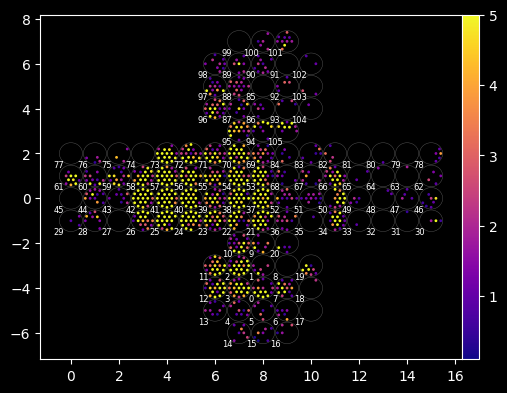

In [35]:
# Find a two ring event to test on
evt_num =5

cut_time = 17

data = {'digi_hit_pmt':[],'digi_hit_time':[],'digi_hit_charge':[]}

for i in range(len(data_raw['digi_hit_time'][evt_num])):
    if 0<data_raw['digi_hit_time'][evt_num][i]<cut_time:
        wcte_pmt = sim_wcte_mapping[data_raw['digi_hit_pmt'][evt_num][i]+1]
        
        data['digi_hit_time'].append(data_raw['digi_hit_time'][evt_num][i])
        data['digi_hit_pmt'].append(wcte_pmt)
        data['digi_hit_charge'].append(data_raw['digi_hit_charge'][evt_num][i])
        
lf_data = np.array([data['digi_hit_pmt'],data['digi_hit_charge'],data['digi_hit_time']]).T

plot_event(lf_data,0)

In [36]:
r1 = [11,3,0,7,18,19,34,50,66,82,83,105,94,95,71,72,56,40,24]
r2 = [102,92,86,69,53,52,51,50,65,80]
r3 = [9,21,20,19,33,49,66,83,68,37,21]

We now need to get the PMT positions and hit times

In [37]:
hall = Device.open_file('/eos/user/j/jrimmer/Geometry/examples/wcte_bldg157.geo')
wcte = hall.wcds[0]

ml_data = {'pmt_pos':[],'pmt_id':[], 'hit_charge':[], 'hit_time':[]}
for i in range(len(lf_data)):
    pmt = int(lf_data[i][0]%100)
    slot = int(lf_data[i][0]//100)
    
    pmt_pos = np.array(wcte.mpmts[slot].pmts[pmt].get_placement('est')['location'])
    
    ml_data['pmt_pos'].append(pmt_pos)
    ml_data['pmt_id'].append(lf_data[i][0])
    ml_data['hit_charge'].append(lf_data[i][1])
    ml_data['hit_time'].append(lf_data[i][2])
    
    
    
ml_data['pmt_pos'] = np.array(ml_data['pmt_pos'])
ml_data['pmt_id'] = np.array(ml_data['pmt_id'])
ml_data['hit_charge'] = np.array(ml_data['hit_charge'])
ml_data['hit_time'] = np.array(ml_data['hit_time'])

# ml_data['ring1'] = np.array(r1)
# ml_data['ring2'] = np.array(r2)
# ml_data['ring3'] = np.array(r3)
ml_data['n_rings_true'] = 2

In [38]:
with open('./sample_data/wcsim/multi_rings/pion_500MeV_x0y0zn1350_three_ring_ev'+str(evt_num)+'.pkl','wb') as f:
    pickle.dump(ml_data,f)

In [39]:
vc = 299.792458 / 1.333  # mm/ns

pmt_locs_all = ml_data['pmt_pos']
hit_times_all = ml_data['hit_time']
hit_charges_all = ml_data['hit_charge']
pmt_ids_all = ml_data['pmt_id']

# Tune this. I found 2.0 keeps more of the ring;
# 4.0 gives a cleaner ring-core finder result.
charge_min = 2

#mask = time_mask & (hit_charges_all >= charge_min)
mask = (hit_charges_all >= charge_min)

pmt_locs = pmt_locs_all[mask]
hit_times = hit_times_all[mask]
hit_charges = hit_charges_all[mask]
pmt_ids = pmt_ids_all[mask]

print(f"Using {mask.sum()} / {len(mask)} hits for ring finding")
# result = rf.find_two_rings_from_hits(
#     pmt_locs=pmt_locs,
#     hit_times=hit_times,
#     hit_charges=hit_charges,
#     pmt_ids=pmt_ids,
#     vertex=(0.0, 0.0, -1350.0),
#     vc=vc,
#     ring1=ml_data.get("ring1"),   # optional, validation only
#     ring2=ml_data.get("ring2"),   # optional, validation only
#     truth_pick=False,
# )

# Build event from your already-filtered hit arrays
event = make_event_dict(
    pmt_locs=pmt_locs,
    hit_times=hit_times,
    hit_charges=hit_charges,
    pmt_ids=pmt_ids,
)

# Use the correct/approximate event vertex.
# For your x0y0zn1350 samples this should usually be:
vertex = (0.0, 0.0, -1350.0)

result = find_variable_rings(
    event,
    vertex=vertex,
    max_rings=3,
)

print_variable_ring_summary(result)
ring_labels = result.hit_labels

Using 606 / 941 hits for ring finding
Ring finder version: v10.4_GEOMETRY_CONTINUITY_PARTITION
Selected rings: 2
Runtime: 2.034 s
Active slots: 44
Selected candidates:
  ring 1: theta=22.5 deg, slots=23, rms=0.0441, kind=hough
  ring 2: theta=21.8 deg, slots=23, rms=0.0389, kind=hough
Model-order diagnostics:
  K=1: score=2185.7, reward=2450.6, supports=[3968.1], theta_span=0.0, dmin=inf
  K=2: score=2743.2, reward=3255.0, supports=[1850.0, 2298.1], theta_span=0.7, dmin=0.299 | 2-ring accepted: similar cone angle but distinct axes/new residual coverage (dmin=0.299, reward_gain=804.5)
  K=3: score=2977.2, reward=3755.8, supports=[1703.1, 1929.0, 849.1], theta_span=47.4, dmin=0.267 | 3-ring veto: one model pair is too similar


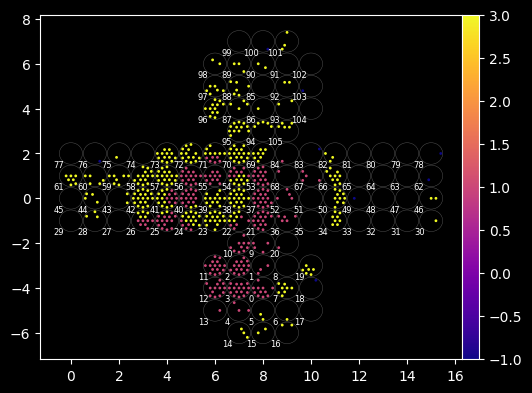

In [40]:
ring_mask = ring_labels==0
ring_labels[ring_mask] = 3
plot_event(np.array([pmt_ids,ring_labels]).T,0,vmax = 3,vmin=-1)

In [34]:
file = '1kpi+_500MeV_x0y0zn1348.root'
fname = folder+ file

se_name = "secondary_electron"
sep_name = 'secondary_e_photons'
ck_name = 'ck_step'
all_name = 'all_photons'
n = 1000000   # number of entries to load

# Get the mapping between wcsim and wcte PMT positions
wcte_mapping = np.loadtxt('../tables/wcsim_wcte_mapping.txt')

with uproot.open(fname) as f:
#     t = f[se_name]
#     arr = t.arrays(library="ak", entry_stop=n)
    
#     t_sep = f[sep_name]
#     arr_sep = t_sep.arrays(library="ak", entry_stop=n)
    
    t_ck = f[ck_name]
    arr_ck = t_ck.arrays(library="ak", entry_stop=n)
    
    t_all = f[all_name]
    arr_all = t_all.arrays(library="ak", entry_stop=n)

# df_se = ak.to_dataframe(arr).reset_index(drop=True)
# df_sep = ak.to_dataframe(arr_sep).reset_index(drop=True)
df_ck = ak.to_dataframe(arr_ck).reset_index(drop=True)
df_all = ak.to_dataframe(arr_all).reset_index(drop=True)


In [42]:
import numpy as np

# Particle masses in MeV/c^2
# Assumes data_raw["track_energy"] is total energy in MeV
PID_MASS_MEV = {
    22: 0.0,              # gamma
    11: 0.51099895,       # e-
    -11: 0.51099895,      # e+
    13: 105.6583755,      # mu-
    -13: 105.6583755,     # mu+
    111: 134.9768,        # pi0
    211: 139.57039,       # pi+
    -211: 139.57039,      # pi-
    321: 493.677,         # K+
    -321: 493.677,        # K-
    130: 497.611,         # K0L
    310: 497.611,         # K0S
    2212: 938.27208816,   # proton
    -2212: 938.27208816,  # anti-proton
    2112: 939.56542052,   # neutron
    -2112: 939.56542052,  # anti-neutron
}

track_id = np.asarray(data_raw["track_id"][evt_num])
track_pid = np.asarray(data_raw["track_pid"][evt_num])
track_energy = np.asarray(data_raw["track_energy"][evt_num])
track_start_pos = np.asarray(data_raw["track_start_position"][evt_num])
track_stop_pos = np.asarray(data_raw["track_stop_position"][evt_num])
track_start_time = np.asarray(data_raw["track_start_time"][evt_num])

# Keep secondary particles and remove nuclei / ion-like Geant4 PDG codes
# Also require the secondary particle to start at t <= 20 ns
base_mask = (
    (track_id > 1)
    & (np.abs(track_pid) <= 1e8)
    & (track_start_time <= 20.0)
)

candidates = []

for idx in np.where(base_mask)[0]:
    pid = int(track_pid[idx])

    if pid not in PID_MASS_MEV:
        print(f"Skipping unknown PID {pid} at index {idx}")
        continue

    mass = PID_MASS_MEV[pid]
    total_energy = float(track_energy[idx])
    kinetic_energy = total_energy - mass

    candidates.append({
        "idx": idx,
        "track_id": track_id[idx],
        "pid": pid,
        "mass": mass,
        "total_energy": total_energy,
        "kinetic_energy": kinetic_energy,
        "start_pos": track_start_pos[idx],
        "stop_pos": track_stop_pos[idx],
        "start_time": track_start_time[idx],
    })

if len(candidates) == 0:
    print("No valid non-nucleus secondary particles with known masses and start_time <= 20 ns found in this event.")
else:
    candidates_sorted = sorted(
        candidates,
        key=lambda x: x["kinetic_energy"],
        reverse=True
    )

    top_two = candidates_sorted[:2]

    for rank, particle in enumerate(top_two, start=1):
        print(f"\nRank {rank}:")
        print("array index:", particle["idx"])
        print("track_id:", particle["track_id"])
        print("pid:", particle["pid"])
        print("mass [MeV]:", particle["mass"])
        print("total energy [MeV]:", particle["total_energy"])
        print("kinetic energy [MeV]:", particle["kinetic_energy"])
        print("track start position:", particle["start_pos"])
        print("track stop position:", particle["stop_pos"])
        print("track start time [ns]:", particle["start_time"])


Rank 1:
array index: 83
track_id: 133630
pid: 2212
mass [MeV]: 938.27208816
total energy [MeV]: 1035.914794921875
kinetic energy [MeV]: 97.64270676187505
track start position: [ -3.5412114 -44.092567   56.912037 ]
track stop position: [ -2.464314 -43.556713  60.195827]
track start time [ns]: 6.969745

Rank 2:
array index: 90
track_id: 133637
pid: 2212
mass [MeV]: 938.27208816
total energy [MeV]: 1001.793212890625
kinetic energy [MeV]: 63.52112473062505
track start position: [ -2.464314 -43.556713  60.195827]
track stop position: [ -1.6371233 -43.2156     63.44504  ]
track start time [ns]: 7.258336


In [43]:
np.unique(np.array(df_ck[df_ck['event']==evt_num]['step_proc']),return_counts = True)


(array(['Cerenkov', 'Transportation', 'hIoni', 'hadElastic',
        'pi+Inelastic'], dtype=object),
 array([1178,    1,   45,    1,    1]))

In [44]:
mask_ck = (df_ck['event']==evt_num) & (df_ck['step_proc']== 'hadElastic')
df_ck[mask_ck]

,event,trackID,step,pdg,n_ck,x,y,z,t,ke,ke_pre,ke_post,edep,step_len,mat,step_proc
2657,2,1,1130,211,92,-9.755522,-42.240864,30.217609,5.852732,143.410797,143.782196,143.410797,0.268985,0.162231,Water,hadElastic


In [26]:
mask_all = (df_all['evt']==evt_num) 
df_all[mask_all]

,evt,trk,par,pdg,muAncestorID,edir_x,edir_y,edir_z,ex_cm,ey_cm,ez_cm,et_ns,Estart_MeV,muKE_MeV,muStep,lambda_nm,creator,hit_pmt,end_boundary,end_process
150121,2,96,1,0,1,-0.604167,-0.227734,0.763623,-0.000055,-42.476254,-134.591843,0.007115,500.0,499.796783,2,434.379791,Cerenkov,-1,physMatrix,Transportation
150122,2,97,1,0,1,0.253416,-0.610468,0.750406,-0.000076,-42.476234,-134.563873,0.008071,500.0,499.796783,2,275.815704,Cerenkov,-1,WCTopCapBlackSheet,Transportation
150123,2,98,1,0,1,-0.286873,0.625364,0.725689,-0.000090,-42.476223,-134.545044,0.008715,500.0,499.796783,2,209.868973,Cerenkov,9612,pmt,Transportation
150124,2,99,1,0,1,0.613533,0.271852,0.741400,-0.000086,-42.476227,-134.550171,0.008539,500.0,499.796783,2,241.503052,Cerenkov,5612,pmt,Transportation
150125,2,100,1,0,1,-0.100043,0.630895,0.769391,-0.000067,-42.476242,-134.575882,0.007661,500.0,499.796783,2,691.340881,Cerenkov,-1,WCBarrel,OpAbsorption
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
269779,2,133625,1,0,1,0.219207,-0.351027,0.910345,-3.747256,-44.071224,56.180397,6.936568,500.0,77.812317,1225,243.123352,Cerenkov,-1,WCBarrelTopBorderRingBlackSheet,Transportation
269780,2,133626,1,0,1,0.045262,-0.041696,0.998105,-3.787195,-44.066429,56.034664,6.929963,500.0,77.812317,1225,441.737732,Cerenkov,-1,physMatrix,Transportation
269781,2,133627,1,0,1,0.488080,-0.080829,0.869048,-3.843604,-44.059658,55.828835,6.920645,500.0,77.812317,1225,353.657684,Cerenkov,3818,pmt,Transportation
269782,2,133628,1,0,1,0.316126,-0.198527,0.927713,-3.898987,-44.053009,55.626751,6.911512,500.0,77.812317,1225,780.129395,Cerenkov,-1,WCBarrel,OpAbsorption


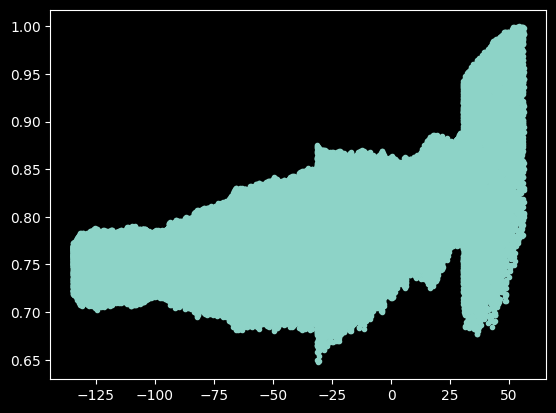

In [27]:
plt.plot(df_all[mask_all]['ez_cm'],df_all[mask_all]['edir_z'],'.')
#plt.xlim(-80,None)

(array(['Cerenkov', 'Transportation', 'hIoni', 'pi+Inelastic'],
       dtype=object),
 array([613,   1,  20,   2]))